# Clientes de Cartão de Crédito: Da Análise Exploratória à Previsão de Churn

## Sobre este projeto

Este notebook é dividido em duas partes:

- **Parte 1 — Análise Exploratória (EDA):** entendemos quem são os clientes, como se comportam e quais padrões existem nos dados. Os dados foram armazenados em um bucket **AWS S3** e analisados com **AWS Athena** via SQL.
- **Parte 2 — Modelo Preditivo de Churn:** usamos **Machine Learning** para prever quais clientes têm maior risco de cancelar o cartão, transformando os insights da EDA em uma ferramenta de decisão com impacto financeiro calculado.

**Dataset:** 10.127 clientes de um banco com informações demográficas, comportamento de consumo, limite de crédito e engajamento com o cartão.

**Stack:** Python · SQL · AWS S3 · AWS Athena · Pandas · scikit-learn · XGBoost · Matplotlib · Seaborn

---

# Parte 1 — Análise Exploratória de Dados (EDA)

## 1.1 Introdução

Nesta primeira parte, analisamos o conjunto de dados de clientes de cartão de crédito respondendo perguntas-chave de negócio:

- Qual perfil possui maior limite de crédito?
- Existe diferença no comportamento de gasto entre homens e mulheres?
- Faixas de salário influenciam número de produtos ou transações?
- Quais grupos apresentam maior valor transacionado?

Os dados foram manipulados, armazenados em um bucket do **AWS S3** e analisados com **AWS Athena**.

## 1.2 Os dados

Os dados apresentam informações dos clientes de um banco com as seguintes colunas:

| Coluna | Descrição |
|--------|-----------|
| Idade | Idade do cliente |
| Sexo | Gênero |
| Dependentes | Número de dependentes |
| Escolaridade | Nível de escolaridade |
| Estado Civil | Casado, solteiro, divorciado |
| Salário Anual | Faixa salarial |
| Tipo de Cartão | Blue, Silver, Gold, Platinum |
| Quantidade de Produtos | Produtos contratados no banco |
| Meses Inativo | Meses sem uso nos últimos 12 |
| Limite de Crédito | Limite disponível |
| Valor das Transações 12m | Total gasto nos últimos 12 meses |
| Quantidade de Transações 12m | Número de transações nos últimos 12 meses |

## 1.3 Visão geral dos dados

**Query:** `SELECT * FROM credito LIMIT 10;`

![](https://github.com/RaphaelCesar/fotos/blob/main/tabelacredito2.png?raw=true)

**Query:** `SELECT COUNT(*) FROM credito;`

Total de **2.564 linhas** na base.

---

**Escolaridades disponíveis:** `SELECT DISTINCT escolaridade FROM credito;`

![](https://github.com/RaphaelCesar/fotos/blob/main/tabelacredito1.png?raw=true)

Diferentes níveis de escolaridade — presença de valores `/na` que serão tratados nas queries.

---

**Estados civis disponíveis:** `SELECT DISTINCT estado_civil FROM credito;`

![](https://github.com/RaphaelCesar/fotos/blob/main/tabelacredito4.png?raw=true)

Três tipos de estado civil além dos valores `/na`.

---

**Faixas salariais:** `SELECT DISTINCT salario_anual FROM credito;`

![](https://github.com/RaphaelCesar/fotos/blob/main/tabelacredito5.png?raw=true)

Dados divididos em faixas salariais — também com valores nulos `/na`.

---

**Tipos de cartão:** `SELECT DISTINCT tipo_cartao FROM credito;`

![](https://github.com/RaphaelCesar/fotos/blob/main/tabelacredito6.png?raw=true)

Quatro tipos de cartões: Blue, Silver, Gold e Platinum.

## 1.4 Análise de dados

### Distribuição por sexo

**Query:** `SELECT count(*), sexo FROM credito GROUP BY sexo`

![](https://github.com/RaphaelCesar/fotos/blob/main/tabelacredito7.png?raw=true)
![](https://github.com/RaphaelCesar/fotos/blob/main/tabelacredito8.png?raw=true)

> Clientes do sexo masculino correspondem a **61%** da base, feminino a **39%**.

---

### Top 10 maiores limites por sexo, cartão e escolaridade

```sql
SELECT max(limite_credito) as limite_credito, escolaridade, tipo_cartao, sexo 
FROM credito 
WHERE escolaridade != 'na' AND tipo_cartao != 'na' 
GROUP BY escolaridade, tipo_cartao, sexo 
ORDER BY limite_credito DESC 
LIMIT 10
```

![](https://github.com/RaphaelCesar/fotos/blob/main/tabelacredito9.png?raw=true)

> Os valores máximos variam de R$34.516,74 a R$34.516,99 — diferença mínima, sugerindo um **teto de limite bem definido pelo banco**. Homens aparecem com maior frequência no topo, com cartões Gold como produto principal.

---

### Valor gasto por sexo

```sql
SELECT max(valor_transacoes_12m), avg(valor_transacoes_12m), min(valor_transacoes_12m), sexo 
FROM credito GROUP BY sexo
```

![](https://github.com/RaphaelCesar/fotos/blob/main/tabelacredito10.png?raw=true)

> **Mulheres** apresentam maior gasto médio e atingem o maior valor extremo de consumo anual. Homens têm comportamento mais regular.

---

### Relação entre salário, sexo e consumo

```sql
SELECT avg(qtd_produtos), avg(valor_transacoes_12m), avg(limite_credito), sexo, salario_anual 
FROM credito WHERE salario_anual != 'na' 
GROUP BY sexo, salario_anual 
ORDER BY avg(valor_transacoes_12m) DESC
```

![](https://github.com/RaphaelCesar/fotos/blob/main/tabelacredito11.png?raw=true)

> **Clientes de menor renda** são os que mais usam o cartão — maior dependência do crédito. Quanto maior a renda, maior o limite concedido, mas **menor o engajamento transacional**.

---

### Limite de crédito por faixa etária

```sql
SELECT CASE
  WHEN idade < 30 THEN 'Menos de 30'
  WHEN idade BETWEEN 30 AND 39 THEN '30-39'
  WHEN idade BETWEEN 40 AND 49 THEN '40-49'
  WHEN idade BETWEEN 50 AND 59 THEN '50-59'
  ELSE '60+'
END AS faixa_etaria, AVG(limite_credito) AS media_limite
FROM credito GROUP BY 1 ORDER BY media_limite DESC;
```

![](https://github.com/RaphaelCesar/fotos/blob/main/tabelacredito12.png?raw=true)
![](https://github.com/RaphaelCesar/fotos/blob/main/tabelacredito13.png?raw=true)

> O limite cresce com a idade até o **pico em 40–49 anos**. Jovens recebem os menores limites por menor histórico de crédito.

---

### Relação entre dependentes e valor gasto

```sql
SELECT dependentes, AVG(valor_transacoes_12m) AS media_gasto
FROM credito GROUP BY dependentes ORDER BY dependentes;
```

![](https://github.com/RaphaelCesar/fotos/blob/main/tabelacredito14.png?raw=true)

> Clientes **sem dependentes** gastam mais — maior liberdade financeira. Útil para segmentação de ofertas e limites.

---

### Correlação entre meses inativos e valor gasto

```sql
SELECT meses_inativo_12m, AVG(valor_transacoes_12m), AVG(qtd_transacoes_12m)
FROM credito GROUP BY meses_inativo_12m ORDER BY meses_inativo_12m;
```

![](https://github.com/RaphaelCesar/fotos/blob/main/tabelacredito15.png?raw=true)
![](https://github.com/RaphaelCesar/fotos/blob/main/tabelacredito16.png?raw=true)

> Clientes com **2–3 meses inativos** gastam mais que os de uso constante. A partir de 4–5 meses, o gasto cai — indicando risco de churn. Esse padrão motivou a construção do modelo preditivo na Parte 2.

---

### Limite e gasto por tipo de cartão

```sql
SELECT tipo_cartao, AVG(limite_credito), AVG(valor_transacoes_12m)
FROM credito GROUP BY tipo_cartao ORDER BY AVG(limite_credito) DESC;
```

![](https://github.com/RaphaelCesar/fotos/blob/main/tabelacredito17.png?raw=true)

> **Platinum** tem o maior limite, mas não o maior gasto. **Gold** lidera em gasto médio — perfil de maior engajamento financeiro.

## 1.5 Conclusão da EDA

A análise exploratória revelou padrões claros de comportamento:

✔ Renda e idade influenciam principalmente o **limite**, não o engajamento.

✔ Clientes de **baixa renda e jovens** usam mais o cartão como meio de pagamento principal.

✔ **Mulheres** gastam mais na média com maior dispersão de valores.

✔ Clientes **sem dependentes** são mais propensos a gastar.

✔ O cliente **Platinum** recebe limite, mas o **Gold** gasta.

✔ Inatividade de **4+ meses** sinaliza risco de churn — padrão que motivou a Parte 2.

**Estratégias sugeridas por segmento:**
- **Platinum:** campanhas de incentivo ao gasto
- **Gold:** manutenção e aumento de limite
- **Silver/Blue:** educação financeira e cross-sell
- **Inativos 4–6 meses:** campanhas de reativação
- **Jovens e baixa renda:** foco em aquisição pelo alto engajamento

---

> 💡 **A pergunta que ficou:** conseguimos **prever** quais clientes vão cancelar antes que cancelem? A resposta está na Parte 2.

---

# Parte 2 — Modelo Preditivo de Churn com Machine Learning

## 2.1 Contexto

Na EDA identificamos que clientes com 4+ meses de inatividade apresentam queda significativa no engajamento. Mas identificar o padrão **depois** que ele acontece não é suficiente.

Nesta parte, usamos Machine Learning para **prever quais clientes têm maior risco de churn** antes que ele aconteça — transformando um insight em uma ferramenta de decisão.

**Pergunta de negócio:** conseguimos identificar com antecedência os clientes em risco para que o banco possa agir com ofertas de retenção antes do cancelamento?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score, RocCurveDisplay)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## 2.2 Carregando os dados

Utilizamos o dataset público **BankChurners** disponível no Kaggle (`sakshigoyal7/credit-card-customers`).
As duas últimas colunas são removidas por conterem variáveis internas do modelo original do dataset que causariam *data leakage*.

In [2]:

import os


for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if 'BankChurners' in f or 'churner' in f.lower():
            DATA_PATH = os.path.join(root, f)
            print(f'Dataset encontrado: {DATA_PATH}')

df = pd.read_csv(DATA_PATH)
df = df.iloc[:, :-2]  # remove colunas de data leakage

print(f'Dataset carregado: {df.shape[0]:,} linhas, {df.shape[1]} colunas')
df.head()

Dataset encontrado: /kaggle/input/datasets/sakshigoyal7/credit-card-customers/BankChurners.csv
Dataset carregado: 10,127 linhas, 21 colunas


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


## 2.3 Criação da variável alvo (churn)

A coluna `Attrition_Flag` indica se o cliente cancelou ou não. Transformamos em binário:
- `1` = cliente cancelou (churn)
- `0` = cliente ativo

Distribuição da variável alvo:
  Clientes ativos  (0): 8,500 (83.9%)
  Clientes churn   (1): 1,627 (16.1%)

Base desbalanceada: usaremos class_weight="balanced" nos modelos.


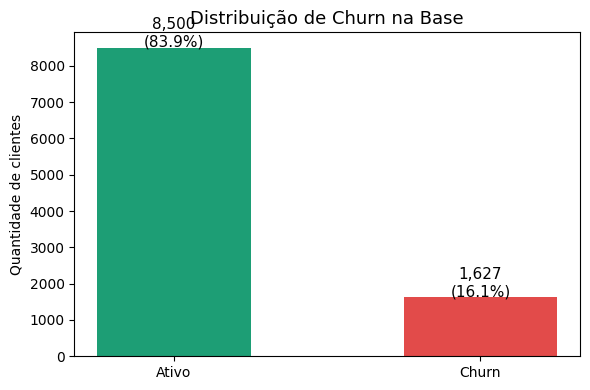

In [3]:
df['churn'] = (df['Attrition_Flag'] == 'Attrited Customer').astype(int)

churn_counts = df['churn'].value_counts()
churn_pct = df['churn'].value_counts(normalize=True) * 100

print('Distribuição da variável alvo:')
print(f'  Clientes ativos  (0): {churn_counts[0]:,} ({churn_pct[0]:.1f}%)')
print(f'  Clientes churn   (1): {churn_counts[1]:,} ({churn_pct[1]:.1f}%)')
print(f'\nBase desbalanceada: usaremos class_weight="balanced" nos modelos.')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Ativo', 'Churn'], churn_counts.values, color=['#1D9E75', '#E24B4A'], width=0.5)
ax.set_title('Distribuição de Churn na Base', fontsize=13)
ax.set_ylabel('Quantidade de clientes')
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 30, f'{v:,}\n({churn_pct.values[i]:.1f}%)', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## 2.4 Engenharia de features

Criamos 3 variáveis derivadas que capturam comportamentos relevantes não explícitos nas colunas originais:

| Feature | Fórmula | Intuição |
|---------|---------|----------|
| `utilizacao_limite` | saldo rotativo ÷ limite total | Quanto do limite o cliente usa |
| `ticket_medio` | valor total ÷ qtd transações | Valor médio por compra |
| `transacoes_por_mes` | transações ÷ meses como cliente | Frequência de uso |

In [4]:
df['utilizacao_limite'] = (df['Total_Revolving_Bal'] / df['Credit_Limit']).round(4)
df['ticket_medio'] = (df['Total_Trans_Amt'] / df['Total_Trans_Ct']).round(2)
df['transacoes_por_mes'] = (df['Total_Trans_Ct'] / df['Months_on_book']).round(2)

print('Novas features criadas:')
print(df[['utilizacao_limite', 'ticket_medio', 'transacoes_por_mes']].describe().round(2))

Novas features criadas:
       utilizacao_limite  ticket_medio  transacoes_por_mes
count           10127.00      10127.00            10127.00
mean                0.27         62.61                1.92
std                 0.28         26.40                0.91
min                 0.00         19.14                0.19
25%                 0.02         47.52                1.27
50%                 0.18         55.79                1.86
75%                 0.50         65.47                2.36
max                 1.00        190.19                9.77


## 2.5 Preparação e divisão treino/teste

In [5]:
drop_cols = ['CLIENTNUM', 'Attrition_Flag', 'churn']
cat_cols = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

df_model = df.drop(columns=drop_cols).copy()

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

X = df_model
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {X_train.shape[0]:,} linhas')
print(f'Teste:  {X_test.shape[0]:,} linhas')
print(f'Features: {X_train.shape[1]}')

Treino: 8,101 linhas
Teste:  2,026 linhas
Features: 22


## 2.6 Treinamento dos modelos

Treinamos 3 modelos de complexidade crescente para comparação:

| Modelo | Abordagem |
|--------|-----------|
| **Regressão Logística** | Baseline linear — simples e interpretável |
| **Random Forest** | Ensemble de 200 árvores de decisão |
| **XGBoost** | Gradient boosting — corrige erros iterativamente |

Como a base é desbalanceada (~16% churn), usamos `class_weight='balanced'` para que o modelo não ignore a classe minoritária.

In [6]:
models = {
    'Regressão Logística': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        n_estimators=200, random_state=42, eval_metric='logloss', verbosity=0
    )
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    results[name] = {'model': model, 'y_pred': y_pred, 'y_proba': y_proba, 'auc': auc}
    print(f'\n{"="*45}\n{name}  |  AUC-ROC: {auc:.4f}\n{"="*45}')
    print(classification_report(y_test, y_pred, target_names=['Ativo', 'Churn']))


Regressão Logística  |  AUC-ROC: 0.9213
              precision    recall  f1-score   support

       Ativo       0.96      0.85      0.90      1701
       Churn       0.51      0.83      0.63       325

    accuracy                           0.84      2026
   macro avg       0.74      0.84      0.77      2026
weighted avg       0.89      0.84      0.86      2026


Random Forest  |  AUC-ROC: 0.9875
              precision    recall  f1-score   support

       Ativo       0.96      0.99      0.97      1701
       Churn       0.94      0.78      0.85       325

    accuracy                           0.96      2026
   macro avg       0.95      0.89      0.91      2026
weighted avg       0.96      0.96      0.95      2026


XGBoost  |  AUC-ROC: 0.9909
              precision    recall  f1-score   support

       Ativo       0.98      0.98      0.98      1701
       Churn       0.90      0.89      0.90       325

    accuracy                           0.97      2026
   macro avg       0.94

## 2.7 Comparação dos modelos — Curva ROC

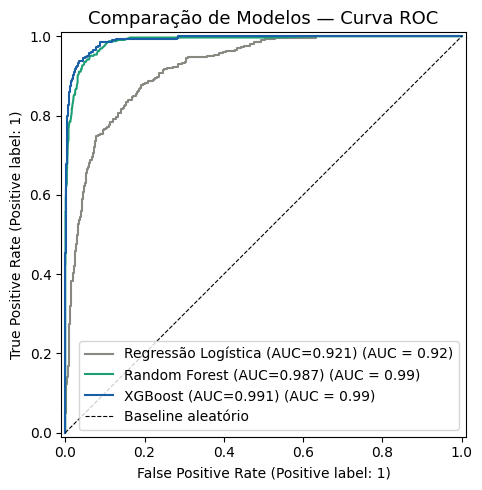

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

cores = {'Regressão Logística': '#888780', 'Random Forest': '#1D9E75', 'XGBoost': '#185FA5'}

for name, res in results.items():
    RocCurveDisplay.from_predictions(
        y_test, res['y_proba'],
        name=f"{name} (AUC={res['auc']:.3f})",
        ax=ax, color=cores[name]
    )

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Baseline aleatório')
ax.set_title('Comparação de Modelos — Curva ROC', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 2.8 Feature Importance — O que mais influencia o churn?

O XGBoost obteve o melhor AUC-ROC (0.991). Analisamos quais variáveis ele considerou mais importantes para a previsão.

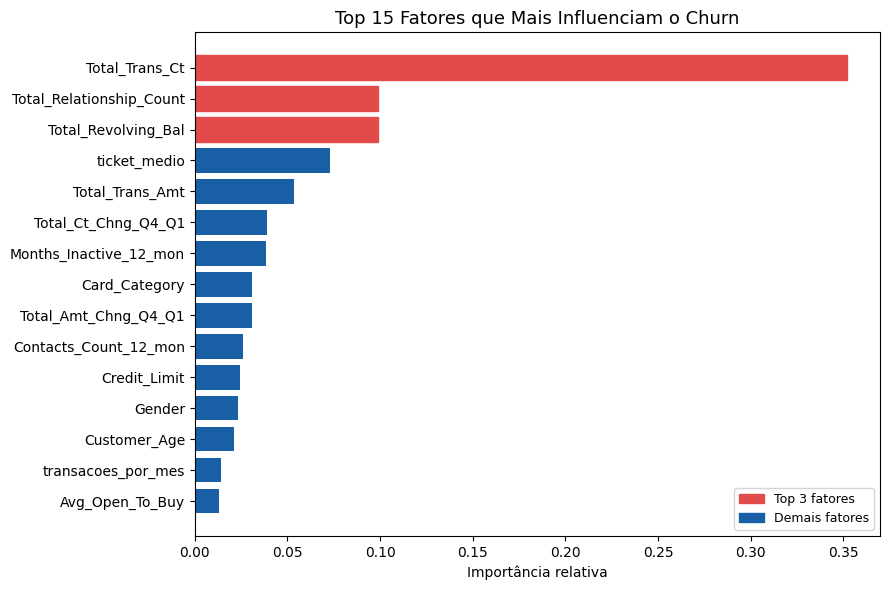


Top 5 fatores de churn:
  Total_Trans_Ct: 0.3521
  Total_Relationship_Count: 0.0988
  Total_Revolving_Bal: 0.0988
  ticket_medio: 0.0731
  Total_Trans_Amt: 0.0537


In [8]:
best_model = results['XGBoost']['model']

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importance_df['feature'][::-1], importance_df['importance'][::-1], color='#185FA5')
ax.set_title('Top 15 Fatores que Mais Influenciam o Churn', fontsize=13)
ax.set_xlabel('Importância relativa')

for i, bar in enumerate(bars):
    if i >= len(bars) - 3:
        bar.set_color('#E24B4A')

ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='#E24B4A', label='Top 3 fatores'),
    plt.Rectangle((0,0),1,1, color='#185FA5', label='Demais fatores')
], loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

print('\nTop 5 fatores de churn:')
for _, row in importance_df.head(5).iterrows():
    print(f'  {row["feature"]}: {row["importance"]:.4f}')

## 2.9 Impacto de negócio

Identificar clientes em risco é só metade do trabalho. A outra metade é quantificar o que isso significa em receita.

In [9]:
df_test = X_test.copy()
df_test['churn_real'] = y_test.values
df_test['prob_churn'] = results['XGBoost']['y_proba']
df_test['valor_transacoes'] = df.loc[X_test.index, 'Total_Trans_Amt'].values

threshold_top10 = df_test['prob_churn'].quantile(0.90)
alto_risco = df_test[df_test['prob_churn'] >= threshold_top10]

total_clientes_teste = len(df_test)
clientes_alto_risco = len(alto_risco)
churn_real_alto_risco = alto_risco['churn_real'].sum()
receita_em_risco = alto_risco['valor_transacoes'].sum()

print('=' * 55)
print('ANÁLISE DE IMPACTO DE NEGÓCIO')
print('=' * 55)
print(f'\nClientes no conjunto de teste:          {total_clientes_teste:,}')
print(f'Clientes identificados como alto risco: {clientes_alto_risco:,} (top 10%)')
print(f'Desses, quantos realmente churnam:      {churn_real_alto_risco:,} ({churn_real_alto_risco/clientes_alto_risco*100:.0f}%)')
print(f'\nReceita transacionada em risco:         R$ {receita_em_risco:,.0f}')
print(f'Ticket médio desses clientes:           R$ {alto_risco["valor_transacoes"].mean():,.0f}')
print(f'\nSe o banco retivesse 30% desses clientes com uma oferta:')
print(f'  Receita preservada estimada: R$ {receita_em_risco * 0.30:,.0f}')
print('=' * 55)

ANÁLISE DE IMPACTO DE NEGÓCIO

Clientes no conjunto de teste:          2,026
Clientes identificados como alto risco: 203 (top 10%)
Desses, quantos realmente churnam:      200 (99%)

Receita transacionada em risco:         R$ 683,191
Ticket médio desses clientes:           R$ 3,365

Se o banco retivesse 30% desses clientes com uma oferta:
  Receita preservada estimada: R$ 204,957


## 2.10 Conclusão

Este projeto evoluiu a análise exploratória de clientes de cartão de crédito para um **modelo preditivo de churn** capaz de identificar clientes em risco com alta precisão.

### Resultados dos modelos

| Modelo | AUC-ROC |
|--------|---------|
| Regressão Logística (baseline) | 0.921 |
| Random Forest | 0.987 |
| **XGBoost (melhor modelo)** | **0.991** |

### Os 3 principais fatores de churn

1. **Total_Trans_Ct** — clientes com menor frequência de transações são os que mais cancelam
2. **Total_Relationship_Count** — clientes com menos produtos no banco têm maior risco
3. **Total_Revolving_Bal** — saldo rotativo baixo sinaliza menor engajamento financeiro

A feature `ticket_medio`, criada durante a engenharia de features, entrou no **top 4 de importância** — confirmando que variáveis derivadas podem agregar valor real ao modelo.

### Impacto de negócio

Ao focar nos **10% de clientes com maior probabilidade de churn**, o modelo identificou **203 clientes com 99% de precisão**.

- Receita transacionada em risco: **R&#36; 683.191**
- Ticket médio: **R&#36; 3.365/cliente**
- Receita preservável com campanha de retenção (30% de conversão): **~R&#36; 204.957**

### Conclusão estratégica

Monitorar a **frequência de transações** mensalmente e acionar campanhas proativas para clientes com queda superior a 20% nas últimas 4 semanas pode ser a ação de maior retorno com menor custo para o negócio — abordando menos de 10% da base com 99% de assertividade.

---

**Stack:** Python · Pandas · scikit-learn · XGBoost · Matplotlib · SQL · AWS S3 · AWS Athena · Google Colab